In [1]:
from transformers import DetrForObjectDetection, DetrConfig
from torchinfo import summary
import torch
import torch.nn as nn

def prune_resnet_backbone(model, pruning_dict):
    """
    Updated for Hugging Face DetrForObjectDetection structure.
    pruning_dict: {stage_number: blocks_to_keep}
    """
    # 1. Reach the internal DETR model
    # If using PEFT, we go through get_base_model()
    curr_model = model.get_base_model() if hasattr(model, "get_base_model") else model
    
    # 2. Correct path to the ResNet object in HF Transformers
    # model.model.backbone -> DetrConvEncoder
    # model.model.backbone.backbone -> DetrResnetBackbone
    # model.model.backbone.backbone.model -> The actual ResNet with layer1, layer2, etc.
    try:
        backbone = curr_model.model.backbone.backbone.model
    except AttributeError:
        # Fallback for some versions of the library
        backbone = curr_model.model.backbone.model
        
    print(f"Successfully reached backbone: {type(backbone).__name__}")

    for stage_num, keep_count in pruning_dict.items():
        stage_name = f"layer{stage_num}"
        if not hasattr(backbone, stage_name):
            print(f"Warning: Stage {stage_num} ({stage_name}) not found. Skipping.")
            continue
            
        stage = getattr(backbone, stage_name)
        total_blocks = len(stage)
        
        # Guard: Ensure we keep at least the downsampling block (index 0)
        if keep_count < 1:
            keep_count = 1
            
        if keep_count >= total_blocks:
            continue

        # Replace unwanted blocks with Identity
        for i in range(keep_count, total_blocks):
            stage[i] = nn.Identity()
            
        print(f"Pruned Stage {stage_num}: Reduced from {total_blocks} to {keep_count} active blocks.")
        
def prune_transformer_layers(model, encoder_keep=None, decoder_keep=None):
    """
    Prunes the Transformer encoder and decoder layers.
    encoder_keep: Number of layers to keep in the encoder (default 6)
    decoder_keep: Number of layers to keep in the decoder (default 6)
    """
    curr_model = model.get_base_model() if hasattr(model, "get_base_model") else model
    
    # Path: model.model.encoder.layers and model.model.decoder.layers
    transformer = curr_model.model
    
    # 1. Prune Encoder
    if encoder_keep is not None:
        layers = transformer.encoder.layers
        total = len(layers)
        if encoder_keep < 1: encoder_keep = 1
        if encoder_keep < total:
            for i in range(encoder_keep, total):
                layers[i] = nn.Identity()
            print(f"Pruned Transformer Encoder: Kept {encoder_keep}/{total} layers.")

    # 2. Prune Decoder
    if decoder_keep is not None:
        layers = transformer.decoder.layers
        total = len(layers)
        if decoder_keep < 1: decoder_keep = 1
        if decoder_keep < total:
            for i in range(decoder_keep, total):
                layers[i] = nn.Identity()
            print(f"Pruned Transformer Decoder: Kept {decoder_keep}/{total} layers.")

ABLATION_DICT = {
    1: 3, # 3 in total
    2: 4, # 4 in total
    3: 6, # 6 in total
    4: 1  # 3 in total
}

TRANSFORMER_ABLATION = {
    "encoder": 6, # 6 in total
    "decoder": 6  # 6 in total
}

config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
config.num_labels = 2

# Load the model (or use your existing 'model' variable)
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
#model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", config=config, ignore_mismatched_sizes=True)  # Adjust num_labels as needed

prune_resnet_backbone(model, ABLATION_DICT)

# This prints the entire layer-by-layer architecture
print(model)

# Create a dummy input to trace the shapes
# DETR expects [batch, channels, height, width]
dummy_input = torch.randn(1, 3, 800, 800) 

summary(model, input_data=dummy_input, depth=3)

/home/pau/miniconda3/envs/cv_final/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 663.33it/s, Materializing param=model.query_position_embeddings.weight]                 
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be 

Successfully reached backbone: FeatureListNet
Pruned Stage 4: Reduced from 3 to 1 active blocks.
DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvEncoder(
      (model): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): DetrFrozenBatchNorm2d()
        (act1): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): DetrFrozenBatchNorm2d()
            (drop_block): Identity()
            (act2): ReLU(inplace=True)
            (aa): Identity()
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), strid

Layer (type:depth-idx)                                            Output Shape              Param #
DetrForObjectDetection                                            [1, 625, 256]             --
├─DetrModel: 1-1                                                  [1, 625, 256]             25,600
│    └─DetrConvEncoder: 2-1                                       [1, 256, 200, 200]        --
│    │    └─FeatureListNet: 3-1                                   [1, 256, 200, 200]        14,542,016
│    └─Conv2d: 2-2                                                [1, 256, 25, 25]          524,544
│    └─DetrSinePositionEmbedding: 2-3                             [1, 625, 256]             --
│    └─DetrEncoder: 2-4                                           [1, 625, 256]             --
│    │    └─ModuleList: 3-2                                       --                        7,890,432
│    └─DetrDecoder: 2-5                                           [1, 100, 256]             --
│    │    └─ModuleLis

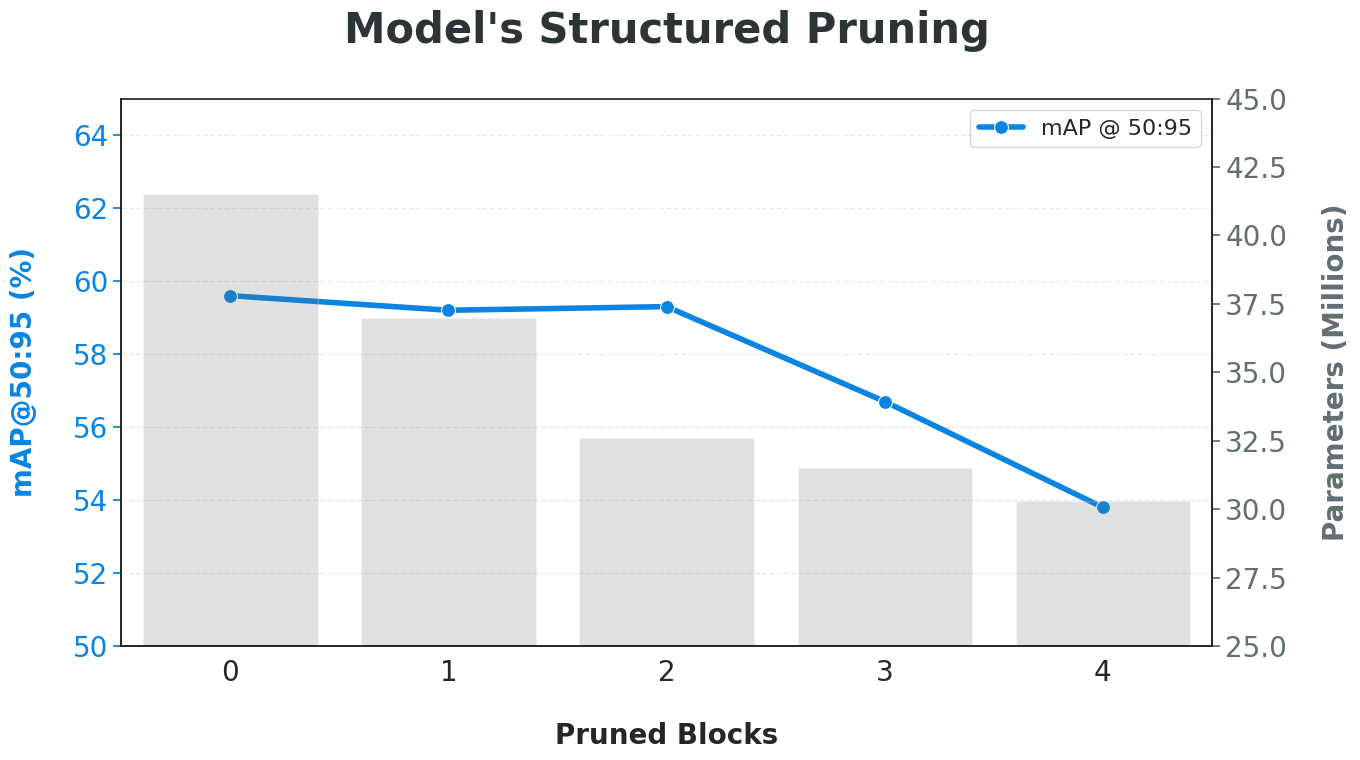

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_final_academic_ablation():
    # --- 1. SET YOUR SIZES HERE ---
    FONTS = {
        'title': 30,
        'axis_labels': 20,
        'tick_labels': 20,
        'data_labels': 16,
        'legend': 16,
        'line_width': 4,
        'marker_size': 10
    }

    # 2. Manual Metrics 
    data = {
        "Config": ["0", "1", "2", "3", "4"],
        "mAP": [59.6, 59.2, 59.3, 56.7, 53.8],
        "Params": [41.5, 37.0, 32.6, 31.5, 30.3]
    }
    df = pd.DataFrame(data)
    
    # 3. Scale Configuration
    MAP_Y_LIMITS = (50, 65)       
    PARAM_Y_LIMITS = (25, 45)     

    # 4. Style Setup
    PRIMARY_COLOR = "#0984e3"    # Royal Blue
    SECONDARY_COLOR = "#636e72"  # Graphite Grey
    TEXT_COLOR = "#2d3436"

    sns.set_style("white")
    plt.rcParams.update({
        'font.size': FONTS['tick_labels'],
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'font.family': 'sans-serif'
    })

    fig, ax1 = plt.subplots(figsize=(14, 8))

    # 5. mAP Line
    sns.lineplot(data=df, x="Config", y="mAP", marker="o", 
                 markersize=FONTS['marker_size'], linewidth=FONTS['line_width'], 
                 color=PRIMARY_COLOR, ax=ax1, label="mAP @ 50:95", zorder=3)
    
    # 6. Parameter Bars
    ax2 = ax1.twinx()
    sns.barplot(data=df, x="Config", y="Params", color=SECONDARY_COLOR, alpha=0.2, ax=ax2, zorder=1)
    
    # 7. Manual Scale Setting
    ax1.set_ylim(MAP_Y_LIMITS)
    ax2.set_ylim(PARAM_Y_LIMITS)

    # 8. Apply Fonts from Variable
    ax1.set_title("Model's Structured Pruning", fontsize=FONTS['title'], pad=40, color=TEXT_COLOR)
    ax1.set_xlabel("Pruned Blocks", fontsize=FONTS['axis_labels'], labelpad=25)
    
    ax1.set_ylabel("mAP@50:95 (%)", color=PRIMARY_COLOR, fontsize=FONTS['axis_labels'], labelpad=25)
    ax2.set_ylabel("Parameters (Millions)", color=SECONDARY_COLOR, fontsize=FONTS['axis_labels'], labelpad=25)

    ax1.tick_params(axis='both', labelsize=FONTS['tick_labels'])
    ax2.tick_params(axis='both', labelsize=FONTS['tick_labels'])
    ax1.tick_params(axis='y', colors=PRIMARY_COLOR)
    ax2.tick_params(axis='y', colors=SECONDARY_COLOR)

    ax1.legend(fontsize=FONTS['legend'], loc='upper right')
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=ax1, top=True, right=False)

    plt.tight_layout()
    plt.savefig("C5_Ablation_Variable_Fonts.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_final_academic_ablation()